<a href="https://colab.research.google.com/github/mglagan/mglagan.github.io/blob/main/UrbanMobility.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **This code is for the partial fulfillment of GE 197 - GE	197:	Spatial	Data	Engineering	and	Spatial	Data	Science**



---



### **🚉 Sustainable Urban Mobility: Unlocking Metro Manila's Transit Potential**


Welcome to our journey into the transformative world of sustainable urban mobility! As Metro Manila continues to grow, the need for a more accessible, inclusive, and efficient transit system becomes increasingly urgent. This project evaluates how recent railway expansions impact public transit accessibility while addressing the United Nations Sustainable Development Goals (SDGs)—particularly SDG 11: Sustainable Cities and Communities.

### **🎯 Objectives of the Study**

This study seeks to measure public transit accessibility using isochrone maps. These maps visually represent how far one can travel within specific timeframes, revealing which areas are easily reachable via Metro Manila's railway system. Furthermore, we compare accessibility before and after the opening of the new railway stations, analyzing whether these developments have reduced travel times and bridged accessibility gaps. Lastly, we overlay accessibility data with population density through bi-variate mapping to identify areas that would benefit most from further transit improvements.

### **🖥️ How to Run this algorithm?**

*   This script was constructed in google collab and will need to be run using google collab
*   A google account with access to the group's database of spatial data is required to re-run the entire script
*   However, all relevant results of the code, many the shapfile of maps and some simple map layouts, are all ready done and available to view in this script
*   Dependecies and modules used are
    *  osmnx
    *  mapclassify
    *  geopandas
    *  networkx
    *  numpy
    *  shapely


---






# ISOCHRONE MAPPING

# Data Preprocessing

## Initializing the application

In [ ]:
!pip install osmnx
!pip install mapclassify

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 kB 2.9 MB/s eta 0:00:00


In [ ]:
import osmnx as ox #for OSM data
import matplotlib.pyplot as plt #for visualization
import geopandas as gpd #for GeoDataFrame (DataFrame with geometry column)
import pandas as pd
import networkx as nx
import numpy as np
import mapclassify as mc
from shapely.geometry import Point, LineString, Polygon, MultiPolygon
plt.style.use("dark_background") #for dark background

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Metro Manila Boundary and Driveway (For Plotting)

In [ ]:
ncr = gpd.read_file("/content/drive/Shareddrives/GE 197 GROUP/NCR/ncr.shp")
ncr_loc = ncr.to_crs(epsg=32651)

In [ ]:
road_walk = ox.graph_from_place('Metro Manila, Philippines',network_type='drive')
rw = ox.project_graph(road_walk) # ma-project into tamang epsg
rwn, rwe = ox.graph_to_gdfs(rw) # convert into tuple (containg a gdf)

#rwn = rwn.to_crs(epsg=4326) #set yung nodes to gdf
#rwe = rwe.to_crs(epsg=4326) #set yung edges to gdf


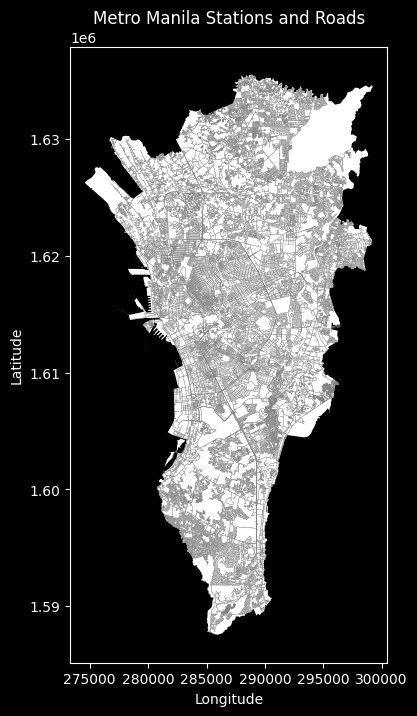

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))

ncr_loc.plot(ax=ax, color="white", label="NCR")
rwe.plot(ax=ax, linewidth=0.2, color='gray', alpha=1)

plt.title('Metro Manila Stations and Roads')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

## Function for the creation of isochrone polygons

In [ ]:
trip_times = [10, 20, 30]

# Function to create isochrone polygons
def make_iso(G, center_node, trip_times, edge_buff=25, node_buff=50, infill=False):
    isochrone_polys = []  # List to store the generated isochrone polygons

    for trip_time in sorted(trip_times, reverse=True):  # Loop through travel times in descending order
        # Create a subgraph containing nodes within the given travel time
        subgraph = nx.ego_graph(G, center_node, radius=trip_time, distance="time")

        # Extract node coordinates from the subgraph and create GeoDataFrame
        node_points = [Point((data["x"], data["y"])) for _, data in subgraph.nodes(data=True)]
        nodes_gdf = gpd.GeoDataFrame({"id": subgraph.nodes()}, geometry=node_points)
        nodes_gdf = nodes_gdf.set_index("id")  # Set node IDs as the index

        # Extract edge geometries, or create them from start and end node coordinates
        edge_lines = []
        for n_fr, n_to in subgraph.edges():
            f = nodes_gdf.loc[n_fr].geometry  # Geometry of the "from" node
            t = nodes_gdf.loc[n_to].geometry  # Geometry of the "to" node
            edge_lookup = G.get_edge_data(n_fr, n_to)[0].get("geometry", LineString([f, t]))
            edge_lines.append(edge_lookup)  # Add edge geometry to the list

        # Buffer nodes and edges to create continuous isochrone shapes
        n = nodes_gdf.buffer(node_buff).geometry  # Buffer around nodes
        e = gpd.GeoSeries(edge_lines).buffer(edge_buff).geometry  # Buffer around edges
        all_gs = list(n) + list(e)  # Combine node and edge buffers

        # Merge into a single shape using unary_union (or union_all for the future)
        new_iso = gpd.GeoSeries(all_gs).union_all()# Updated to use union_all() instead of unary_union

        # If the result is a MultiPolygon, iterate through its components
        if isinstance(new_iso, MultiPolygon):  # Check if it's a MultiPolygon
            for polygon in new_iso.geoms:  # Use .geoms to access individual Polygons
                if infill:
                    polygon = Polygon(polygon.exterior)  # Ensure it's a Polygon
                isochrone_polys.append(polygon)
        else:
            # If it's a single Polygon, proceed as usual
            if infill:
                new_iso = Polygon(new_iso.exterior)  # Ensure it's a Polygon
            isochrone_polys.append(new_iso)

    return isochrone_polys  # Return the list of isochrone polygons

# Isochrone mapping of walking accessibility of metro manila train stations

## ISOCHRONE FOR EXISTING STATIONS

In [ ]:
stations_old = gpd.read_file("/content/drive/Shareddrives/GE 197 GROUP/Stations/stations/old_stations.shp")

Processing station (14.657559146743798, 121.02113871017606) for 30 minutes
Processing station (14.65743023339633, 121.00389808109783) for 30 minutes
Processing station (14.65431566386565, 120.98383445843204) for 30 minutes
Processing station (14.644426538544145, 120.98355882156656) for 30 minutes
Processing station (14.636050194797365, 120.9823390142227) for 30 minutes
Processing station (14.630537988310325, 120.98149839792582) for 30 minutes
Processing station (14.622659167895025, 120.98289181080922) for 30 minutes
Processing station (14.616676556994772, 120.98276541379363) for 30 minutes
Processing station (14.611137339241129, 120.98243343127061) for 30 minutes
Processing station (14.605316515729545, 120.98211667730365) for 30 minutes
Processing station (14.5991724325076, 120.98136324449038) for 30 minutes
Processing station (14.592800118139495, 120.98161603852172) for 30 minutes
Processing station (14.582547511232653, 120.98460844979604) for 30 minutes
Processing station (14.5765755

<ipython-input-11-9e80fae77aaf>:49: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


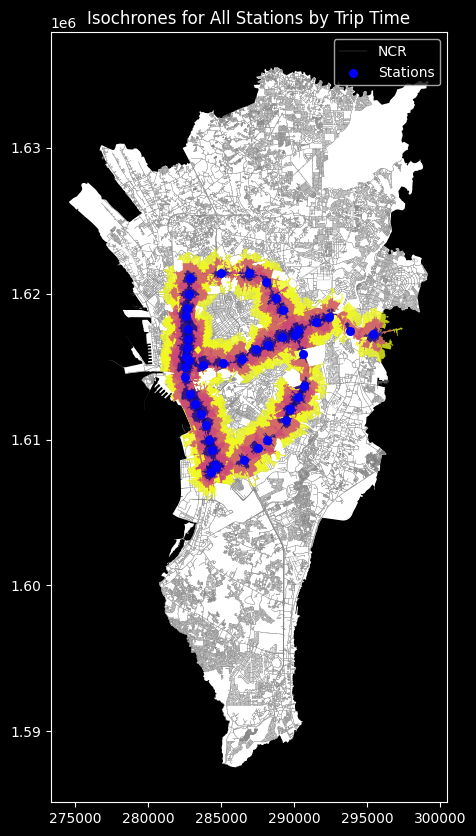

In [ ]:
stations_old = stations_old.to_crs(epsg=4326)

fig, ax = plt.subplots(figsize=(10, 10))  # Create plot axis

iso_colors = ox.plot.get_colors(n=len(trip_times), cmap='plasma', start=0)
# Loop through each trip time in sorted order
for trip_time in sorted(trip_times, reverse=True):
    # Generate isochrone polygons for all stations for the current trip time
    for idx, row in stations_old.iterrows():
        location_point = (row.geometry.y, row.geometry.x)  # Extract lat-lon from station geometry
        print(f"Processing station {location_point} for {trip_time} minutes")

        # Create a walking network for the area around the station (in EPSG:4326)
        station_g = ox.graph_from_point(location_point, dist=2500, network_type="walk")

        # Reproject the graph to EPSG:32651 (UTM zone 51N)
        station_g_projected = ox.project_graph(station_g)

        # Add travel time as an edge attribute based on walking speed
        travel_speed = 4.23  # Walking speed in km/h
        for u, v, key, data in station_g_projected.edges(keys=True, data=True):
            data["time"] = data["length"] / (travel_speed * 1000 / 60)  # Convert km/h to m/min

        # Find the nearest network node to the station's location (in EPSG:4326)
        center_node = ox.nearest_nodes(station_g, X=location_point[1], Y=location_point[0])

        # Generate the isochrone polygon for the current trip time
        isochrone_polys = make_iso(station_g_projected, center_node, [trip_time], edge_buff=25, node_buff=0, infill=True)

        # Plot the isochrone polygons
        if isochrone_polys:
            isochrones_gdf_old = gpd.GeoDataFrame(
                {"geometry": isochrone_polys}, crs="EPSG:32651"
            )
            isochrones_gdf_old.plot(ax=ax, color=iso_colors[trip_times.index(trip_time)], alpha=0.8, zorder=3)
        else:
            print(f"No isochrones for station at {location_point} for trip time {trip_time}")

        output_path = f'/content/downloads_existing/existing_{trip_time}/{trip_time}_{idx}.shp'
        isochrones_gdf_old.to_file(output_path, driver='ESRI Shapefile')

# Plot the stations on the map (ensure they're in EPSG:32651 for alignment)
ncr_loc.plot(ax=ax, color="white", label="NCR", zorder=1)
rwe.plot(ax=ax, color="gray", linewidth=0.2, label="NCR", zorder=2)
stations_old = stations_old.to_crs("EPSG:32651")  # Reproject stations to match isochrones
stations_old.plot(ax=ax, color="blue", markersize=30, label="Stations", zorder=4)

# Add legend and finalize the plot
plt.legend()
plt.title("Isochrones for All Stations by Trip Time")
plt.show()  # Display the plot

## ISOCHRONE FOR EXISTING & NEW STATIONS

In [ ]:
stations_new = gpd.read_file("/content/drive/Shareddrives/GE 197 GROUP/Stations/stations/new_stations.shp")

Processing station (14.657559146743798, 121.02113871017606) for 30 minutes
Processing station (14.65743023339633, 121.00389808109783) for 30 minutes
Processing station (14.65431566386565, 120.98383445843204) for 30 minutes
Processing station (14.644426538544145, 120.98355882156656) for 30 minutes
Processing station (14.636050194797365, 120.9823390142227) for 30 minutes
Processing station (14.630537988310325, 120.98149839792582) for 30 minutes
Processing station (14.622659167895025, 120.98289181080922) for 30 minutes
Processing station (14.616676556994772, 120.98276541379363) for 30 minutes
Processing station (14.611137339241129, 120.98243343127061) for 30 minutes
Processing station (14.605316515729545, 120.98211667730365) for 30 minutes
Processing station (14.5991724325076, 120.98136324449038) for 30 minutes
Processing station (14.592800118139495, 120.98161603852172) for 30 minutes
Processing station (14.582547511232653, 120.98460844979604) for 30 minutes
Processing station (14.5765755

<ipython-input-10-1d97306ebf10>:50: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


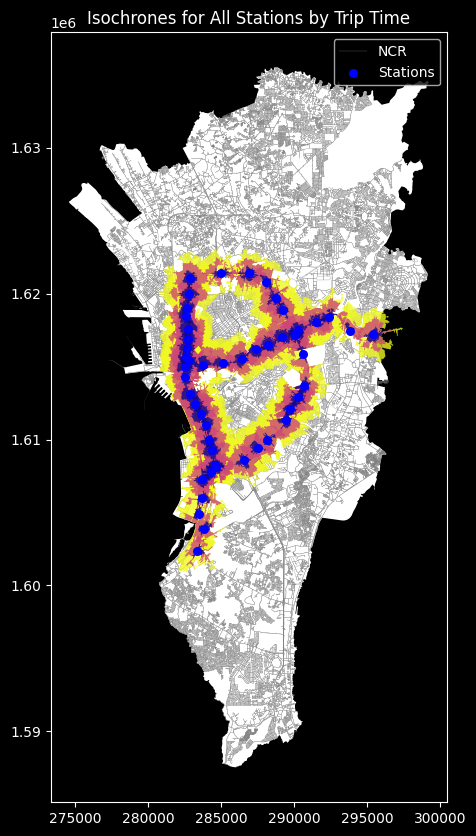

In [ ]:
stations_new = stations_new.to_crs(epsg=4326)

fig, ax = plt.subplots(figsize=(10, 10))  # Create plot axis

iso_colors = ox.plot.get_colors(n=len(trip_times), cmap='plasma', start=0)
# Loop through each trip time in sorted order
for trip_time in sorted(trip_times, reverse=True):
    # Generate isochrone polygons for all stations for the current trip time
    for idx, row in stations_new.iterrows():
        location_point = (row.geometry.y, row.geometry.x)  # Extract lat-lon from station geometry
        print(f"Processing station {location_point} for {trip_time} minutes")

        # Create a walking network for the area around the station (in EPSG:4326)
        station_g = ox.graph_from_point(location_point, dist=2500, network_type="walk")

        # Reproject the graph to EPSG:32651 (UTM zone 51N)
        station_g_projected = ox.project_graph(station_g)

        # Add travel time as an edge attribute based on walking speed
        travel_speed = 4.23  # Walking speed in km/h
        for u, v, key, data in station_g_projected.edges(keys=True, data=True):
            data["time"] = data["length"] / (travel_speed * 1000 / 60)  # Convert km/h to m/min

        # Find the nearest network node to the station's location (in EPSG:4326)
        center_node = ox.nearest_nodes(station_g, X=location_point[1], Y=location_point[0])

        # Generate the isochrone polygon for the current trip time
        isochrone_polys = make_iso(station_g_projected, center_node, [trip_time], edge_buff=25, node_buff=0, infill=True)

        # Plot the isochrone polygons
        if isochrone_polys:
            isochrones_gdf_new = gpd.GeoDataFrame(
                {"geometry": isochrone_polys}, crs="EPSG:32651"
            )
            isochrones_gdf_new.plot(ax=ax, color=iso_colors[trip_times.index(trip_time)], alpha=0.8, zorder=3)
        else:
            print(f"No isochrones for station at {location_point} for trip time {trip_time}")

        output_path = f'/content/downloads_new/new_{trip_time}/{trip_time}_{idx}.shp'
        isochrones_gdf_new.to_file(output_path, driver='ESRI Shapefile')


# Plot the stations on the map (ensure they're in EPSG:32651 for alignment)
ncr_loc.plot(ax=ax, color="white", label="NCR", zorder=1)
rwe.plot(ax=ax, color="gray", linewidth=0.2, label="NCR", zorder=2)
stations_new = stations_new.to_crs("EPSG:32651")  # Reproject stations to match isochrones
stations_new.plot(ax=ax, color="blue", markersize=30, label="Stations", zorder=4)

# Add legend and finalize the plot
plt.legend()
plt.title("Isochrones for All Stations by Trip Time")
plt.show()  # Display the plot

## Exporting Shapefiles for For Bivariate Maps

In [ ]:
!cp -r downloads_existing /content/drive/MyDrive/

cp: cannot stat 'downloads_existing': No such file or directory


In [ ]:
!cp -r downloads_new /content/drive/MyDrive/

cp: cannot stat 'downloads_new': No such file or directory


# BIVARIATE MAPPING

# Data Preprocessing

## Loading Isochrone Shapefiles

In [ ]:
import geopandas as gpd
import os

In [ ]:
"/content/drive/Shareddrives/GE 197 GROUP/EXPORT/downloads_new/new_10"

# Function to load and merge all shapefiles in a folder
def load_isochrones(folder_path, travel_time):
    gdfs = []
    for file in os.listdir(folder_path):
        if file.endswith('.shp'):
            gdf = gpd.read_file(os.path.join(folder_path, file))
            gdf['travel_time'] = travel_time  # Add travel time as a column
            gdfs.append(gdf)
    return gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True))

# Load existing isochrone shapefiles for each threshold
exisiting_isochrones_10 = load_isochrones("/content/drive/Shareddrives/GE 197 GROUP/EXPORT/downloads_existing/existing_10", travel_time=10)
exisiting_isochrones_20 = load_isochrones("/content/drive/Shareddrives/GE 197 GROUP/EXPORT/downloads_existing/existing_20", travel_time=20)
exisiting_isochrones_30 = load_isochrones("/content/drive/Shareddrives/GE 197 GROUP/EXPORT/downloads_existing/existing_30", travel_time=30)

# Combine all existing isochrones into one GeoDataFrame
existing_isochrone = pd.concat([exisiting_isochrones_30, exisiting_isochrones_20, exisiting_isochrones_10], ignore_index=True)
export_path = '/content/drive/Shareddrives/GE 197 GROUP/EXPORT/Isochrone Combined & Raw/Existing Isochrone/Existing_Isochrone.shp'
existing_isochrone.to_file(export_path, driver='ESRI Shapefile')
print(existing_isochrone.head())

# Load new isochrone shapefiles for each threshold
isochrones_10 = load_isochrones("/content/drive/Shareddrives/GE 197 GROUP/EXPORT/downloads_new/new_10", travel_time=10)
isochrones_20 = load_isochrones("/content/drive/Shareddrives/GE 197 GROUP/EXPORT/downloads_new/new_20", travel_time=20)
isochrones_30 = load_isochrones("/content/drive/Shareddrives/GE 197 GROUP/EXPORT/downloads_new/new_30", travel_time=30)

# Combine all new isochrones into one GeoDataFrame
isochrones = pd.concat([isochrones_30, isochrones_20, isochrones_10], ignore_index=True)
export_path = '/content/drive/Shareddrives/GE 197 GROUP/EXPORT/Isochrone Combined & Raw/New Isochrone/New_Isochrone.shp'
isochrones.to_file(export_path, driver='ESRI Shapefile')
print(isochrones.head())

/usr/local/lib/python3.10/dist-packages/geopandas/array.py:1638: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as WGS 84 / UTM zone 51N (the single non-null crs provided).
  return GeometryArray(data, crs=_get_common_crs(to_concat))
<ipython-input-8-c3c938841da2>:21: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  existing_isochrone.to_file(export_path, driver='ESRI Shapefile')
/usr/local/lib/python3.10/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'travel_time' to 'travel_tim'
  ogr_write(


                                            geometry  travel_time  FID
0  POLYGON ((287774.803 1610673.451, 287775.779 1...           30  NaN
1  POLYGON ((289349.699 1614685.355, 289348.711 1...           30  NaN
2  POLYGON ((294169.246 1616897.311, 294166.889 1...           30  0.0
3  POLYGON ((288297.424 1611202.229, 288297.082 1...           30  NaN
4  POLYGON ((290002.689 1617084.408, 290002.554 1...           30  0.0


<ipython-input-8-c3c938841da2>:32: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  isochrones.to_file(export_path, driver='ESRI Shapefile')


   FID                                           geometry  travel_time
0    0  POLYGON ((285978.363 1608297.173, 285977.433 1...           30
1    0  POLYGON ((283199.039 1607149.316, 283198.287 1...           30
2    0  POLYGON ((285032.439 1607770.357, 285031.253 1...           30
3    0  POLYGON ((286756.92 1609023.888, 286758.306 16...           30
4    0  POLYGON ((287774.803 1610673.451, 287775.779 1...           30


/usr/local/lib/python3.10/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'travel_time' to 'travel_tim'
  ogr_write(


In [ ]:
print(existing_isochrone['travel_time'].value_counts())
print(existing_isochrone.crs)  # Check the Coordinate Reference System

print(isochrones['travel_time'].value_counts())
print(isochrones.crs)  # Check the Coordinate Reference System

travel_time
20    45
10    45
30    30
Name: count, dtype: int64
EPSG:32651
travel_time
30    50
20    50
10    50
Name: count, dtype: int64
EPSG:32651


## Loading Population Density Data


In [ ]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 45.1 MB/s eta 0:00:00


In [ ]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

In [ ]:
import zipfile

# Define the path to the zip file and the destination folder
zip_file_path = "/content/drive/Shareddrives/GE 197 GROUP/Pop Density/phl_pd_2020_1km_ASCII_XYZ.zip"
extract_path = "/content/PopDensity"

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("File extracted successfully!")

File extracted successfully!


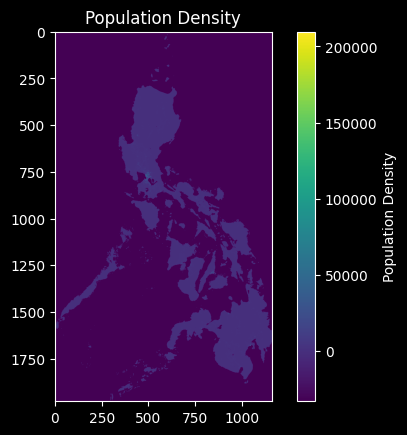

In [ ]:
# Open the ASCII file
population_file = "/content/drive/Shareddrives/GE 197 GROUP/Pop Density/phl_pd_2020_1km_ASCII_XYZ.csv"
with rasterio.open(population_file) as src:
    population_density = src.read(1)  # Read the first band (population density)
    transform = src.transform  # Get the geotransform
    crs = src.crs  # Coordinate Reference System

# Plot population density for reference
plt.imshow(population_density, cmap='viridis')
plt.colorbar(label='Population Density')
plt.title('Population Density')
plt.show()

## READING POPULATION DENSITY DATA

In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# Load the population data as a pandas DataFrame
population_df = pd.read_csv("/content/drive/Shareddrives/GE 197 GROUP/Pop Density/phl_pd_2020_1km_ASCII_XYZ.csv")  # Adjust for .asc if necessary

# Create a geometry column (assuming 'x' and 'y' columns exist for coordinates)
population_df['geometry'] = population_df.apply(lambda row: Point(row['X'], row['Y']), axis=1)

# Convert to GeoDataFrame
population_gdf = gpd.GeoDataFrame(population_df, geometry='geometry')

# Assign CRS to match the coordinate system of your population data
population_gdf = population_gdf.set_crs(epsg=4326)  # Replace with the correct CRS if known


<Axes: >

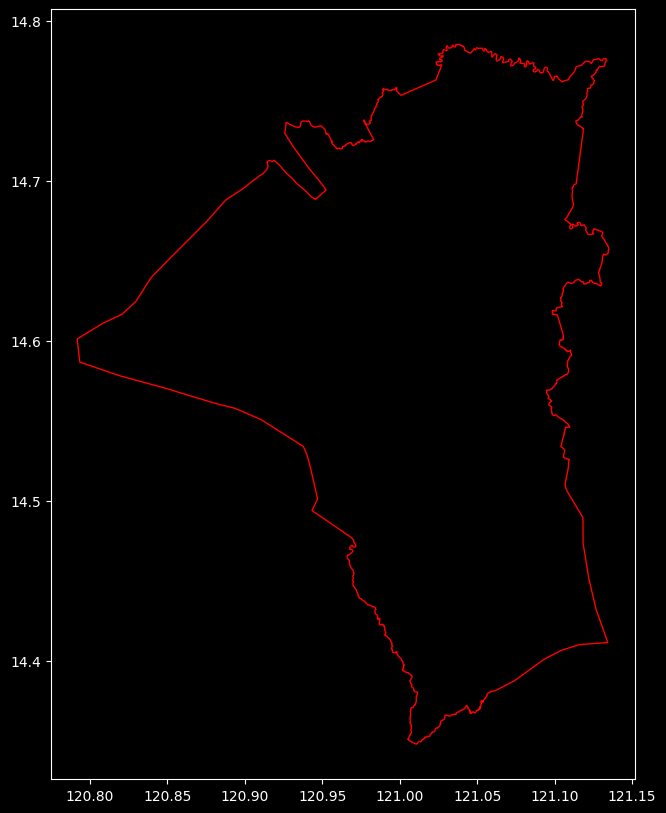

In [ ]:
import osmnx as ox

# Get the boundary for Metro Manila
MM = ox.geocode_to_gdf("Metro Manila, Philippines")

# Ensure the CRS matches the population data
MM = MM.to_crs(population_gdf.crs)
MM = MM.to_crs(epsg=4326)
# Optional: Visualize the boundary
MM.plot(color='none', edgecolor='red', figsize=(10, 10))


In [ ]:
# Clip the population data to Metro Manila
population_gdf = gpd.clip(population_gdf, MM)

# Check the result
print(population_gdf.head())
print(f"Number of rows in Metro Manila population data: {len(population_gdf)}")


                 X          Y             Z                    geometry
103968  121.036250  14.370417   3286.308350  POINT (121.03625 14.37042)
103969  121.044583  14.370417  11968.939453  POINT (121.04458 14.37042)
103887  121.044583  14.378750   8302.374023  POINT (121.04458 14.37875)
103967  121.027916  14.370417   4840.144531  POINT (121.02792 14.37042)
103885  121.027916  14.378750  11928.119141  POINT (121.02792 14.37875)
Number of rows in Metro Manila population data: 767


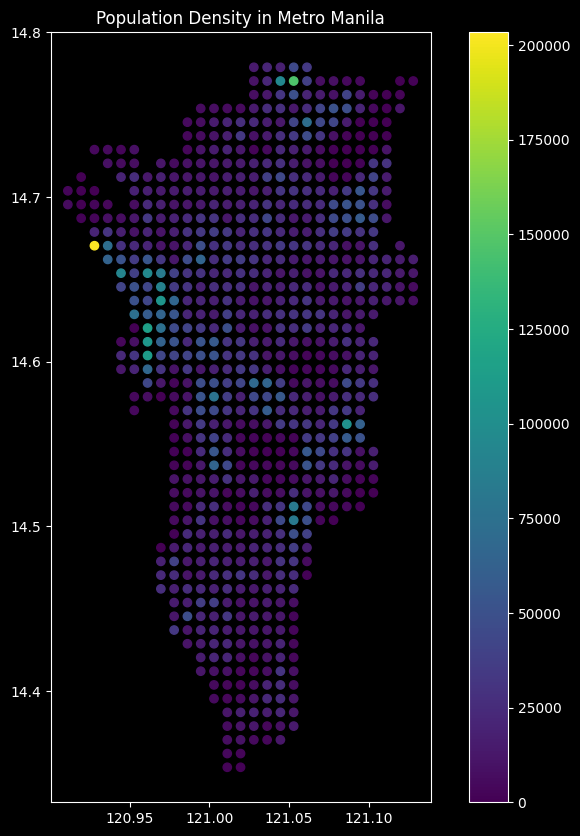

In [ ]:
# Plot the clipped population density data
population_gdf.plot(column='Z', cmap='viridis', legend=True, figsize=(10, 10))
plt.title("Population Density in Metro Manila")
plt.show()


In [ ]:
MM = MM.to_crs(population_gdf.crs)



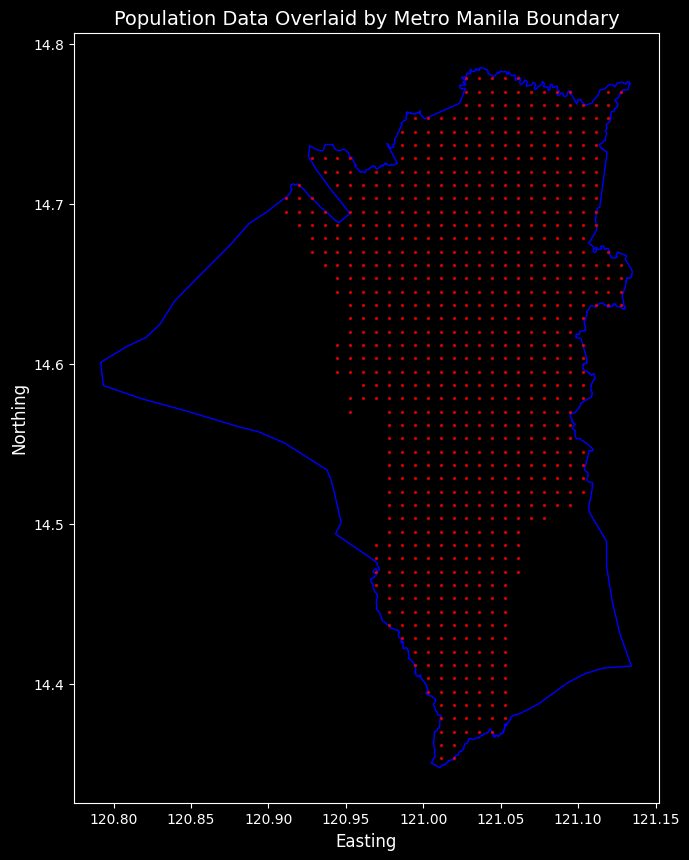

In [ ]:
import matplotlib.pyplot as plt

# Plot administrative boundary (Metro Manila)
ax = MM.plot(color='none', edgecolor='blue', figsize=(10, 10), linewidth=1)

# Plot population points on top of the administrative boundary
population_gdf.plot(ax=ax, color='red', markersize=2, alpha=0.7)

# Add a title and labels
plt.title("Population Data Overlaid by Metro Manila Boundary", fontsize=14)
plt.xlabel("Easting", fontsize=12)
plt.ylabel("Northing", fontsize=12)
plt.show()


In [ ]:
#CHECKING BOUNDS
print("Population Data Bounds:", population_gdf.total_bounds)
print("Metro Manila Bounds:", MM.total_bounds)
print("Metro Manila Bounds:", isochrones.total_bounds)

Population Data Bounds: [120.91124953  14.35375014 121.1279162   14.77875014]
Metro Manila Bounds: [120.7917034  14.3478041 121.1350232  14.7853355]
Metro Manila Bounds: [ 280714.82296277 1600894.86710445  297448.48479871 1623173.28582797]


In [ ]:
# Reproject isochrone data to match population data CRS
isochrones = isochrones.to_crs(population_gdf.crs)
existing_isochrone = existing_isochrone.to_crs(population_gdf.crs)

In [ ]:
#CHECKING CRS
print("existing_isochrone CRS:", existing_isochrone.crs)
print("Isochrones CRS:", isochrones.crs)
print("Population CRS:", population_gdf.crs)


existing_isochrone CRS: EPSG:4326
Isochrones CRS: EPSG:4326
Population CRS: EPSG:4326


##FUNCTIONS FOR CATEGORIES

In [ ]:
def categorize_accessibility(travel_time):
    if travel_time == 10:
        return 'High Accessibility'
    elif travel_time == 20:
        return 'Moderate Accessibility'
    elif travel_time == 30:
        return 'Low Accessibility'
    else:
        return 'Unknown'




In [ ]:

def categorize_population(row):
    if row['Z'] <= 17471.02:
        return 'Low'
    elif row['Z'] <= 35768.58:
        return 'Moderate'
    else:
        return 'High'



In [ ]:
def classify_service(row):
    # Highly Underserved Categories
    if row['population_category'] == 'High' and row['accessibility_category'] == 'Low Accessibility':
        return 'Extremely Underserved'
    elif row['population_category'] == 'Moderate' and row['accessibility_category'] == 'Low Accessibility':
        return 'Very Highly Underserved'
    elif row['population_category'] == 'Low' and row['accessibility_category'] == 'Low Accessibility':
        return 'Moderately Underserved'

    # Adequately Served Categories
    elif row['population_category'] == 'High' and row['accessibility_category'] == 'Moderate Accessibility':
        return 'Highly Underserved'
    elif row['population_category'] == 'Moderate' and row['accessibility_category'] == 'Moderate Accessibility':
        return 'Adequately Served'
    elif row['population_category'] == 'Low' and row['accessibility_category'] == 'Moderate Accessibility':
        return 'Moderately Well-Served'

    # Well-Served Categories
    elif row['population_category'] == 'High' and row['accessibility_category'] == 'High Accessibility':
        return 'Highly Well-Served'
    elif row['population_category'] == 'Moderate' and row['accessibility_category'] == 'High Accessibility':
        return 'Very Highly Well-Served'
    elif row['population_category'] == 'Low' and row['accessibility_category'] == 'High Accessibility':
        return 'Extremely Well-Served'
    else:
        return 'Unknown'  # Catch any unexpected cases


In [ ]:
def classify_service(row):
    # Highly Underserved Categories
    if row['population_category'] == 'High' and row['accessibility_category'] == 'Low Accessibility':
        return 'Extremely Underserved'
    elif row['population_category'] == 'Moderate' and row['accessibility_category'] == 'Low Accessibility':
        return 'Very Highly Underserved'
    elif row['population_category'] == 'Low' and row['accessibility_category'] == 'Low Accessibility':
        return 'Moderately Underserved'

    # Adequately Served Categories
    elif row['population_category'] == 'High' and row['accessibility_category'] == 'Moderate Accessibility':
        return 'Highly Underserved'
    elif row['population_category'] == 'Moderate' and row['accessibility_category'] == 'Moderate Accessibility':
        return 'Adequately Served'
    elif row['population_category'] == 'Low' and row['accessibility_category'] == 'Moderate Accessibility':
        return 'Moderately Well-Served'

    # Well-Served Categories
    elif row['population_category'] == 'High' and row['accessibility_category'] == 'High Accessibility':
        return 'Highly Well-Served'
    elif row['population_category'] == 'Moderate' and row['accessibility_category'] == 'High Accessibility':
        return 'Very Highly Well-Served'
    elif row['population_category'] == 'Low' and row['accessibility_category'] == 'High Accessibility':
        return 'Extremely Well-Served'



##SPATIAL JOIN FOR BIVARIATE MAP

In [ ]:
# Perform a spatial join for existing isochrones
existing_isochrone_with_population = gpd.sjoin(existing_isochrone, population_gdf, how='left', predicate='intersects')

# Check the result
print(existing_isochrone_with_population.head())

# Perform a spatial join for new isochrones
isochrones_with_population = gpd.sjoin(isochrones, population_gdf, how='left', predicate='intersects')

# Check the result
print(isochrones_with_population.head())

                                            geometry  travel_time  FID  \
0  POLYGON ((121.03025 14.56086, 121.03026 14.560...           30  NaN   
0  POLYGON ((121.03025 14.56086, 121.03026 14.560...           30  NaN   
0  POLYGON ((121.03025 14.56086, 121.03026 14.560...           30  NaN   
0  POLYGON ((121.03025 14.56086, 121.03026 14.560...           30  NaN   
0  POLYGON ((121.03025 14.56086, 121.03026 14.560...           30  NaN   

   index_right           X          Y             Z  
0     101717.0  121.052916  14.562083  31193.300781  
0     101718.0  121.061250  14.562083  31863.416016  
0     101611.0  121.052916  14.570417  23295.494141  
0     101506.0  121.052916  14.578750  22964.572266  
0     101823.0  121.044583  14.553750   4569.091797  
   FID                                           geometry  travel_time  \
0    0  POLYGON ((121.01378 14.53925, 121.01377 14.539...           30   
0    0  POLYGON ((121.01378 14.53925, 121.01377 14.539...           30   
0    0  P

In [ ]:
#FUNCTIONS FOR CATEGORIES FOR BIVARIATE OF EXISTING STATIONS
existing_isochrone_with_population['accessibility_category'] = existing_isochrone_with_population['travel_time'].apply(categorize_accessibility)
existing_isochrone_with_population['population_category'] = existing_isochrone_with_population.apply(categorize_population, axis=1)
existing_isochrone_with_population['service_level'] = existing_isochrone_with_population.apply(classify_service, axis=1)

#FUNCTIONS FOR CATEGORIES FOR BIVARIATE WITH NEW STATIONS
isochrones_with_population['accessibility_category'] = isochrones_with_population['travel_time'].apply(categorize_accessibility)
isochrones_with_population['population_category'] = isochrones_with_population.apply(categorize_population, axis=1)
isochrones_with_population['service_level'] = isochrones_with_population.apply(classify_service, axis=1)

In [ ]:
# Define color mapping for service levels
color_mapping = {
    'Extremely Underserved': '#d73027',
    'Very Highly Underserved': '#fc8d59',
    'Moderately Underserved': '#fee08b',
    'Highly Underserved': '#d9ef8b',
    'Adequately Served': '#91cf60',
    'Moderately Well-Served': '#1a9850',
    'Highly Well-Served': '#3288bd',
    'Very Highly Well-Served': '#0055a4',
    'Extremely Well-Served': '#4b0091',
    'Not Serviceable': '#FFFFFF'  # white for areas that are not servicable
}

# Map colors to the service levels for bivariate map for existing stations
existing_isochrone_with_population['color'] = existing_isochrone_with_population['service_level'].map(color_mapping)

# Map colors to the service levels for bivariate map with new stations
isochrones_with_population['color'] = isochrones_with_population['service_level'].map(color_mapping)


In [ ]:
#export raw shapefile for bivariate map for existing stations
export_path = '/content/drive/Shareddrives/GE 197 GROUP/EXPORT/Birvariate Raw/Existing_Bivariate/Existing_Bivariate.shp'
existing_isochrone_with_population.to_file(export_path, driver='ESRI Shapefile')

#export raw shapefile for bivariate map with new stations
export_path = '/content/drive/Shareddrives/GE 197 GROUP/EXPORT/Birvariate Raw/New_Bivariate/New_Bivariate.shp'
isochrones_with_population.to_file(export_path, driver='ESRI Shapefile')

<ipython-input-30-2dc3f2066461>:3: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  existing_isochrone_with_population.to_file(export_path, driver='ESRI Shapefile')
/usr/local/lib/python3.10/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'travel_time' to 'travel_tim'
  ogr_write(
/usr/local/lib/python3.10/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'index_right' to 'index_righ'
  ogr_write(
/usr/local/lib/python3.10/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'accessibility_category' to 'accessibil'
  ogr_write(
/usr/local/lib/python3.10/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'population_category' to 'population'
  ogr_write(
/usr/local/lib/python3.10/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'service_level' to 'service_le'
  ogr_write(
<

# Bivariate mapping of Existing station accessibility with population density

##PLOTTING MAP

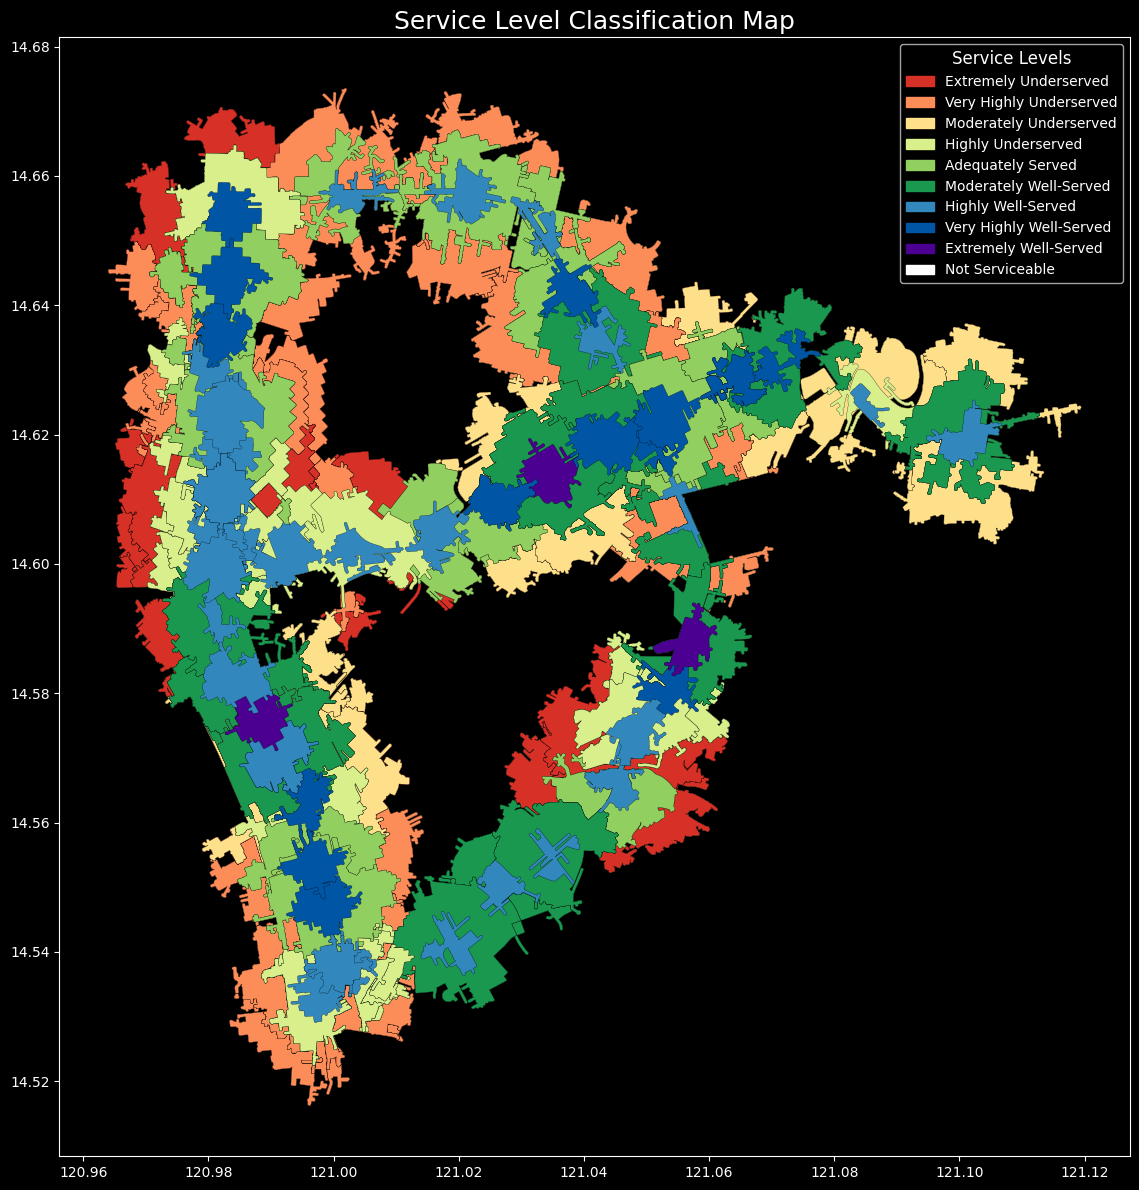

In [ ]:
#PLOTTING WITHOUT OVERLAYING TO QC

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Plot the classified service levels
fig, ax = plt.subplots(1, 1, figsize=(16, 12))  # Increased figure size
existing_isochrone_with_population.plot(ax=ax, color=existing_isochrone_with_population['color'], edgecolor='black', linewidth=0.2)

# Add a title
plt.title("Service Level Classification Map", fontsize=18)

# Create the legend
legend_patches = [mpatches.Patch(color=color, label=label) for label, color in color_mapping.items()]
plt.legend(handles=legend_patches, loc='upper right', title='Service Levels', fontsize=10, title_fontsize=12, frameon=True)

# Improve margins and spacing
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
# Reproject isochrones_with_population to match the CRS of ncr_loc and rwe
existing_isochrone_with_population = existing_isochrone_with_population.to_crs(epsg=32651)


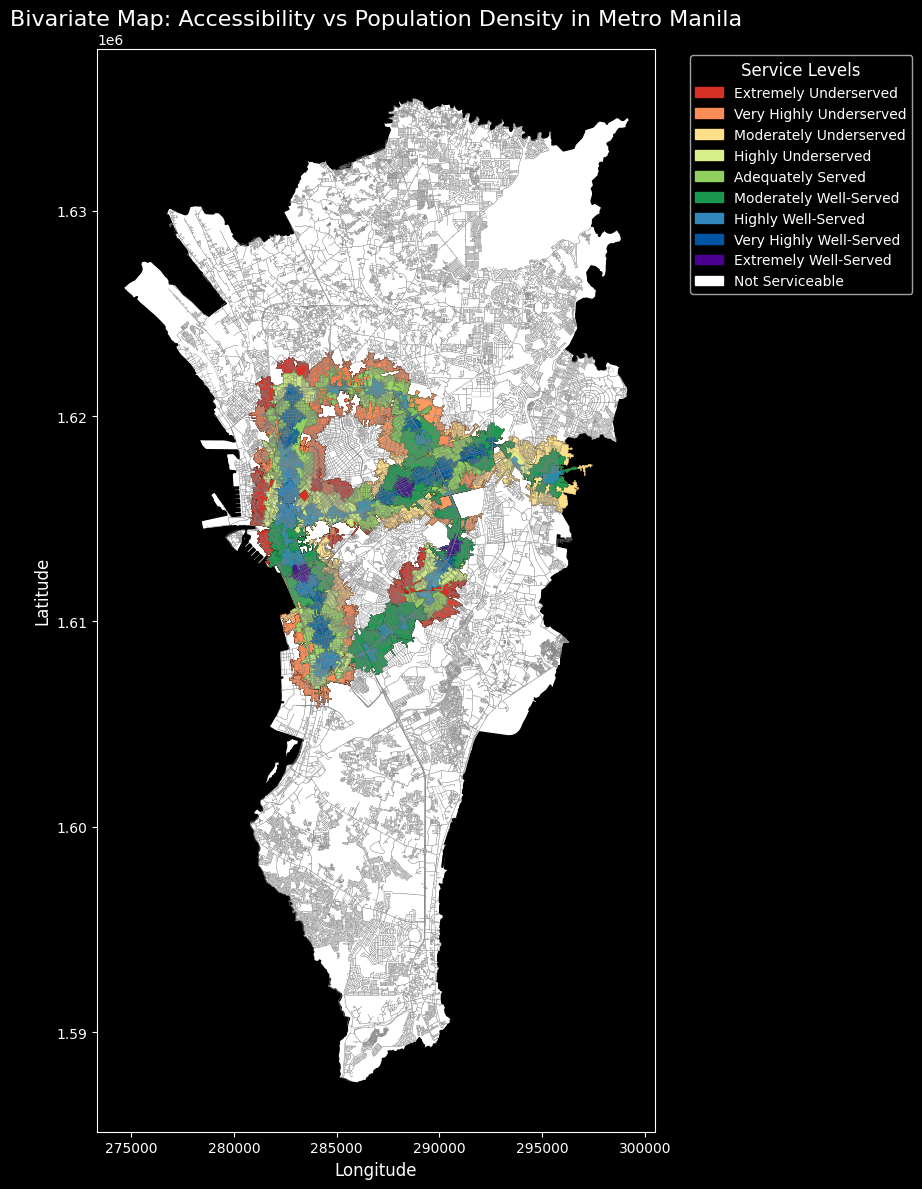

In [ ]:
# Create the base map with Metro Manila boundary and roads
fig, ax = plt.subplots(figsize=(16, 12))  # Increased figure size for better visibility

# Plot Metro Manila boundary
ncr_loc.plot(ax=ax, color="white", edgecolor="black", label="NCR")

# Plot road network
rwe.plot(ax=ax, linewidth=0.2, color="gray", alpha=1, label="Roads")

# Plot isochrones with bivariate map classification
existing_isochrone_with_population.plot(
    ax=ax,
    color=existing_isochrone_with_population['color'],
    edgecolor="black",
    linewidth=0.1,
    alpha=0.8,
    label="existing isochrone"
)

# Add title and labels
plt.title("Bivariate Map: Accessibility vs Population Density in Metro Manila", fontsize=16)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)

# Add legend manually
import matplotlib.patches as mpatches
legend_patches = [mpatches.Patch(color=color, label=label) for label, color in color_mapping.items()]
plt.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', title='Service Levels', fontsize=10, title_fontsize=12)


# Show the map
plt.tight_layout()
plt.show()


In [ ]:
print(existing_isochrone_with_population[['population_category', 'accessibility_category', 'service_level']].head())


  population_category accessibility_category            service_level
0            Moderate      Low Accessibility  Very Highly Underserved
0            Moderate      Low Accessibility  Very Highly Underserved
0            Moderate      Low Accessibility  Very Highly Underserved
0            Moderate      Low Accessibility  Very Highly Underserved
0                 Low      Low Accessibility   Moderately Underserved


## CHECKING FOR OVERLAP

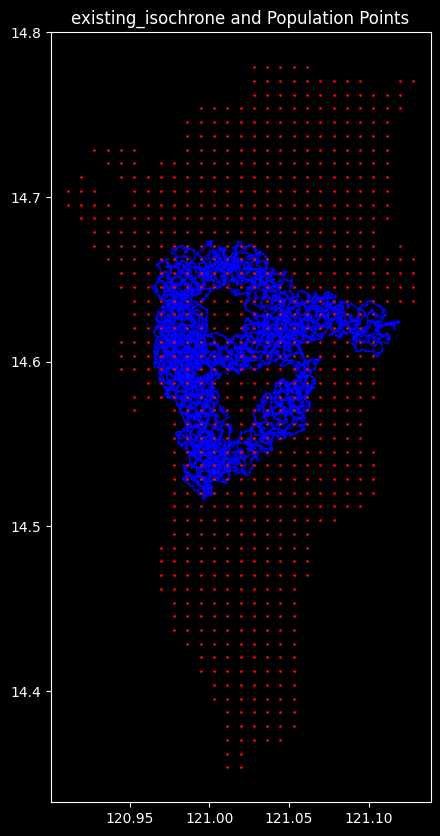

In [ ]:
# Plot the isochrones polygons
ax = existing_isochrone.plot(color='none', edgecolor='blue', figsize=(10, 10))

# Plot the population points on top
population_gdf.plot(ax=ax, color='red', markersize=1)
plt.title("existing_isochrone and Population Points")
plt.show()


##DEFINING POP DENSITY THRESHOLD

In [ ]:


#DEFINING THRESHOLD FOR POPULATION DATA
import mapclassify as mc

# Apply natural breaks classification with k=3 (three categories)
classifier = mc.NaturalBreaks(population_gdf['Z'], k=3)

# Access the breakpoints for Low, Moderate, High categories
print(classifier.bins)  # Breakpoints


[ 22543.9609375   58546.91796875 203349.28125   ]


In [ ]:
print(population_gdf['Z'].describe())


count       767.000000
mean      21709.385589
std       19316.890953
min           0.000000
25%        9560.432617
50%       17128.875000
75%       28954.541992
max      203349.281250
Name: Z, dtype: float64


# Bivariate mapping of Existing stations & New stations accessibility with population density

##PLOTTING MAP

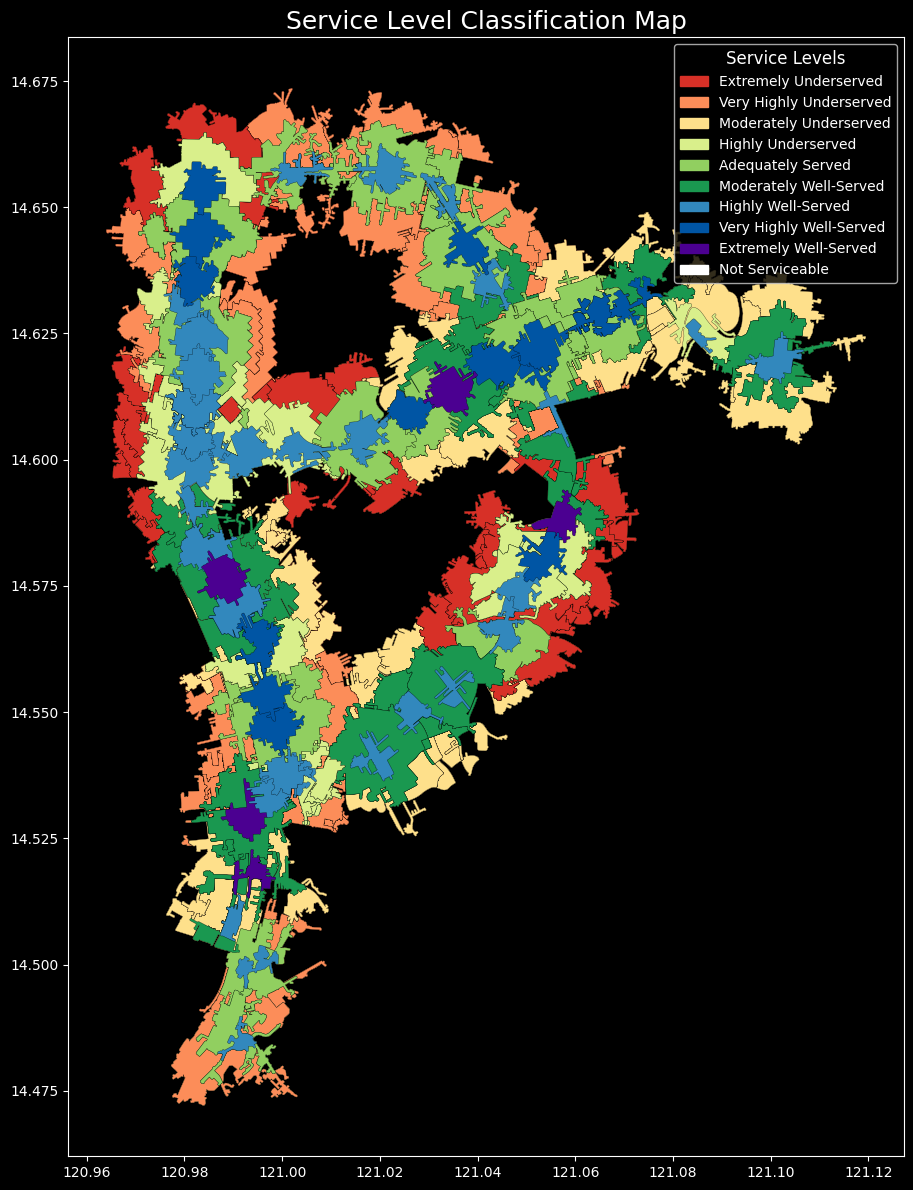

In [ ]:
#PLOTTING WITHOUT OVERLAYING TO QC

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Plot the classified service levels
fig, ax = plt.subplots(1, 1, figsize=(16, 12))  # Increased figure size
isochrones_with_population.plot(ax=ax, color=isochrones_with_population['color'], edgecolor='black', linewidth=0.2)

# Add a title
plt.title("Service Level Classification Map", fontsize=18)

# Create the legend
legend_patches = [mpatches.Patch(color=color, label=label) for label, color in color_mapping.items()]
plt.legend(handles=legend_patches, loc='upper right', title='Service Levels', fontsize=10, title_fontsize=12, frameon=True)

# Improve margins and spacing
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
# Reproject isochrones_with_population to match the CRS of ncr_loc and rwe
isochrones_with_population = isochrones_with_population.to_crs(epsg=32651)


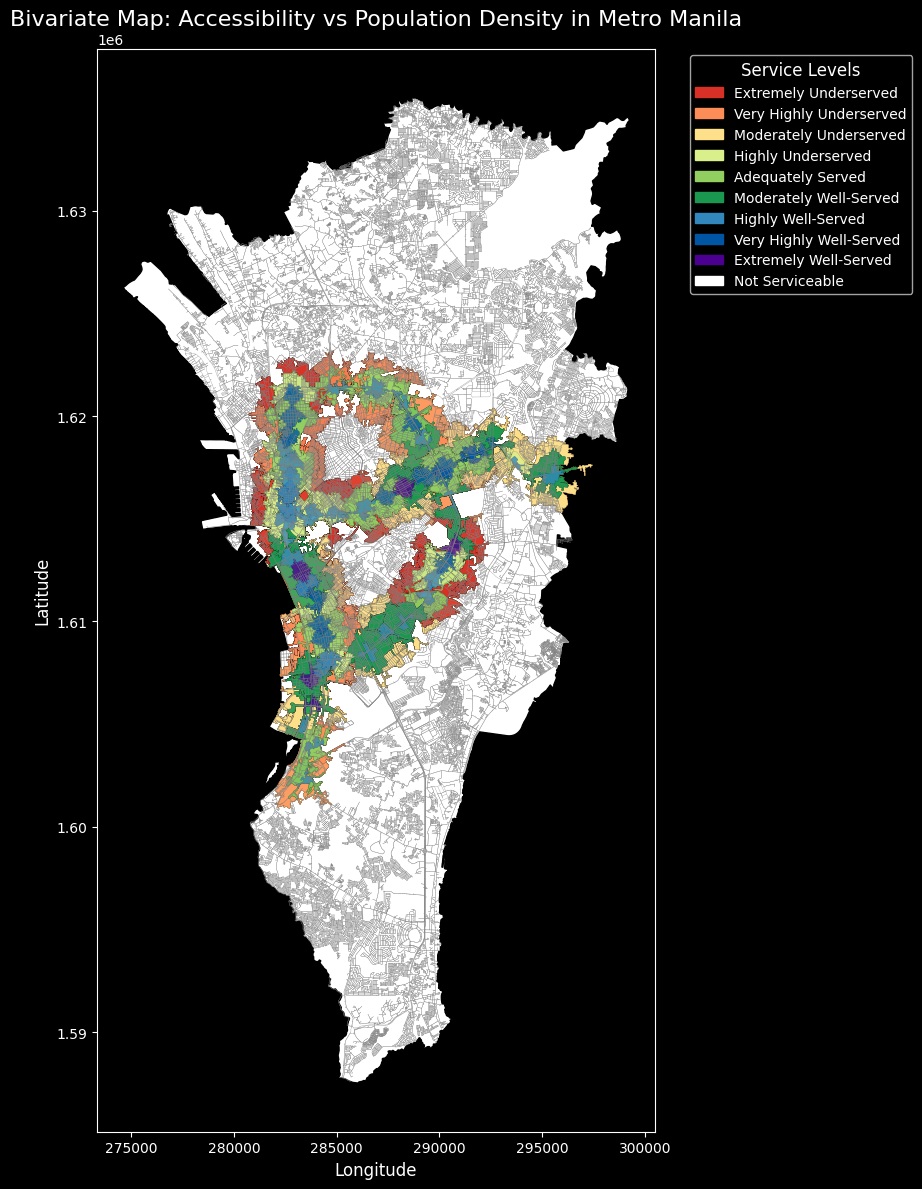

In [ ]:
# Create the base map with Metro Manila boundary and roads
fig, ax = plt.subplots(figsize=(16, 12))  # Increased figure size for better visibility

# Plot Metro Manila boundary
ncr_loc.plot(ax=ax, color="white", edgecolor="black", label="NCR")

# Plot road network
rwe.plot(ax=ax, linewidth=0.2, color="gray", alpha=1, label="Roads")

# Plot isochrones with bivariate map classification
isochrones_with_population.plot(
    ax=ax,
    color=isochrones_with_population['color'],
    edgecolor="black",
    linewidth=0.1,
    alpha=0.8,
    label="Isochrones"
)

# Add title and labels
plt.title("Bivariate Map: Accessibility vs Population Density in Metro Manila", fontsize=16)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)

# Add legend manually
import matplotlib.patches as mpatches
legend_patches = [mpatches.Patch(color=color, label=label) for label, color in color_mapping.items()]
plt.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', title='Service Levels', fontsize=10, title_fontsize=12)


# Show the map
plt.tight_layout()
plt.show()


In [ ]:
print(isochrones_with_population[['population_category', 'accessibility_category', 'service_level']].head())


  population_category accessibility_category           service_level
0                 Low      Low Accessibility  Moderately Underserved
0                 Low      Low Accessibility  Moderately Underserved
0                 Low      Low Accessibility  Moderately Underserved
0                 Low      Low Accessibility  Moderately Underserved
0                 Low      Low Accessibility  Moderately Underserved


## CHECKING FOR OVERLAP

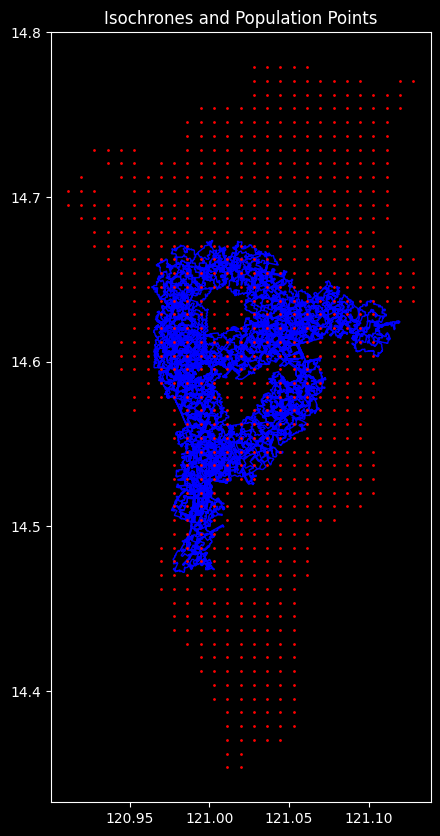

In [ ]:
# Plot the isochrones polygons
ax = isochrones.plot(color='none', edgecolor='blue', figsize=(10, 10))

# Plot the population points on top
population_gdf.plot(ax=ax, color='red', markersize=1)
plt.title("Isochrones and Population Points")
plt.show()


##DEFINING POP DENSITY THRESHOLD

In [ ]:


#DEFINING THRESHOLD FOR POPULATION DATA
import mapclassify as mc

# Apply natural breaks classification with k=3 (three categories)
classifier = mc.NaturalBreaks(population_gdf['Z'], k=3)

# Access the breakpoints for Low, Moderate, High categories
print(classifier.bins)  # Breakpoints


[ 22543.9609375   58546.91796875 203349.28125   ]


In [ ]:
print(population_gdf['Z'].describe())


count       767.000000
mean      21709.385589
std       19316.890953
min           0.000000
25%        9560.432617
50%       17128.875000
75%       28954.541992
max      203349.281250
Name: Z, dtype: float64
